# EBITDA Architecture Optimizer — Post‑Merger Engineering Decisions

**Purpose**  
- Quantify which post‑merger engineering decisions actually drive sustainable EBITDA expansion, and which ones destroy value through cost, disruption, or delayed payback
- The model is intentionally conservative and non‑optimistic, reflecting real industrial post‑merger constraints


## 1. Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## 2. Operating Baseline

In [2]:
BASE_EBITDA = 50_000_000
BASE_REVENUE = 180_000_000
BASE_GROSS_MARGIN = 0.34
ENGINEERING_HEADCOUNT = 120
AVG_ENGINEER_COST = 140_000

## 3. Architecture Decision Options

In [3]:
# Each option represents a realistic post‑merger initiative
options = {
    "Process Standardisation": {
        "capex": 4_000_000,
        "opex_drag": 0.02,
        "margin_uplift": 0.015,
        "delay_months": 6,
        "execution_risk": 0.10
    },
    "System Modularisation": {
        "capex": 12_000_000,
        "opex_drag": 0.04,
        "margin_uplift": 0.035,
        "delay_months": 18,
        "execution_risk": 0.25
    },
    "Automation Upgrade": {
        "capex": 9_000_000,
        "opex_drag": 0.03,
        "margin_uplift": 0.025,
        "delay_months": 12,
        "execution_risk": 0.20
    },
    "Platform Re‑architecture": {
        "capex": 22_000_000,
        "opex_drag": 0.06,
        "margin_uplift": 0.060,
        "delay_months": 30,
        "execution_risk": 0.45
    }
}

## 4. EBITDA Impact Mechanics

In [4]:
DISCOUNT_RATE = 0.12

results = {}

for name, v in options.items():
    # Margin impact net of disruption
    net_margin = BASE_GROSS_MARGIN                  + v["margin_uplift"]                  - v["opex_drag"]

    net_margin = max(net_margin, 0.15)  # floor realism

    # Steady‑state EBITDA
    steady_ebitda = BASE_REVENUE * net_margin

    # Time discount
    timing_discount = 1 / ((1 + DISCOUNT_RATE) ** (v["delay_months"] / 12))

    # Risk‑adjusted EBITDA
    risk_adjusted_ebitda = steady_ebitda * (1 - v["execution_risk"]) * timing_discount

    # Net EBITDA uplift
    uplift = risk_adjusted_ebitda - BASE_EBITDA

    results[name] = uplift

results

{'Process Standardisation': 1280329.8755268976,
 'System Modularisation': -11844992.652137727,
 'Automation Upgrade': -6928571.428571418,
 'Platform Re‑architecture': -24644682.394988462}

## 5. EBITDA Uplift Comparison

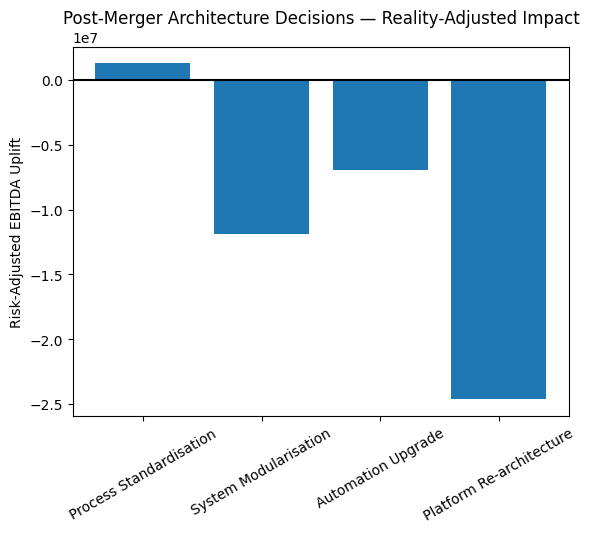

In [5]:
plt.bar(results.keys(), results.values())
plt.axhline(0, color='black')
plt.ylabel("Risk‑Adjusted EBITDA Uplift")
plt.title("Post‑Merger Architecture Decisions — Reality‑Adjusted Impact")
plt.xticks(rotation=30)
plt.show()

## 6. ROI per Engineering Hour

In [6]:
roi_per_engineer = {}

for name, uplift in results.items():
    # Assume 30% of engineering team diverted during project
    eng_cost = ENGINEERING_HEADCOUNT * 0.30 * AVG_ENGINEER_COST
    roi_per_engineer[name] = uplift / eng_cost

roi_per_engineer

{'Process Standardisation': 0.254033705461686,
 'System Modularisation': -2.3501969547892316,
 'Automation Upgrade': -1.3747165532879797,
 'Platform Re‑architecture': -4.889817935513584}

## 7. Capital Efficiency

In [7]:
capex_efficiency = {}
for name, v in options.items():
    capex_efficiency[name] = results[name] / v["capex"]

capex_efficiency

{'Process Standardisation': 0.3200824688817244,
 'System Modularisation': -0.9870827210114772,
 'Automation Upgrade': -0.7698412698412687,
 'Platform Re‑architecture': -1.1202128361358392}

## 8. Decision Matrix

In [8]:
for name in options.keys():
    print(f"{name}: EBITDA Uplift = {results[name]:,.0f}, EBITDA/Capex = {capex_efficiency[name]:.2f}")

Process Standardisation: EBITDA Uplift = 1,280,330, EBITDA/Capex = 0.32
System Modularisation: EBITDA Uplift = -11,844,993, EBITDA/Capex = -0.99
Automation Upgrade: EBITDA Uplift = -6,928,571, EBITDA/Capex = -0.77
Platform Re‑architecture: EBITDA Uplift = -24,644,682, EBITDA/Capex = -1.12


## 9. What This Explicitly Penalises


- Long delays before benefits show up
- Large, fragile architectural changes
- High execution risk even when upside looks attractive
- Ignoring opportunity cost of engineering bandwidth


## 10. Deal Interpretation


Most post‑merger engineering programs **over‑promise and under‑deliver**.

This framework forces every initiative to clear four hurdles:
1. Margin realism
2. Time‑to‑impact
3. Execution risk
4. Capital efficiency

Only a small subset of initiatives should ever be funded in the first 24 months post‑close.
